In [1]:
import os
import json
import gzip
import pandas as pd
import numpy as np

import scipy.sparse as spsparse
import scipy.stats as spstats

from statsmodels.stats.multitest import multipletests as holm
import statsmodels.api as sm

import matplotlib.pylab as plt
import matplotlib.gridspec as gridspec
import matplotlib.transforms as transforms

import seaborn as sns

# correlation with capacity and goverment index

In [73]:
def data_preprocess(name, numpub, start_year, end_year, sig):

    if name=='bootstrap_noselfauthoraff':
        dfself_vars=pd.read_csv('RegressionSelfCitation/SelfCitation_Plus_Covariates_bootstrap_noselfauthoraff_07172025.csv')
    
    elif name=='bootstrap_noselfauthor':
        dfself_vars=pd.read_csv('RegressionSelfCitation/SelfCitation_Plus_Covariates_bootstrap_noselfauthor_07172025.csv')
    
    elif name=='noselfauthor':
        dfself_vars=pd.read_csv('RegressionSelfCitation/SelfCitation_Plus_Covariates_noselfauthor_07172025.csv')
    elif name=='noselfauthoraff':
        dfself_vars=pd.read_csv('RegressionSelfCitation/SelfCitation_Plus_Covariates_noselfauthoraff_07172025.csv')
    else:
        dfself_vars=pd.DataFrame()
        return dfself_vars

        
    dfself_vars=dfself_vars[(dfself_vars['Year']<=end_year)&(dfself_vars['Year']>=start_year)]
    dfself_vars=dfself_vars.dropna(subset=['FracInternationalAuthors','zscore',])
    print(f'number of countries without nan: {dfself_vars['Country'].nunique()}')

    dfself_vars['Year']=dfself_vars['Year'].astype(int)
    
    dfself_vars = dfself_vars[dfself_vars['N']>=numpub]
    print(f'number of countries without nan and pub>50: {dfself_vars['Country'].nunique()}')

    
    conditions = [
        (dfself_vars['significant'] == True) & (dfself_vars['zscore'] < 0),
        (dfself_vars['significant'] == True) & (dfself_vars['zscore'] > 0),
        (dfself_vars['significant'] == False)
    ]
    
    choices = [-1, 1, 0]
    
    dfself_vars['sig_direction'] = np.select(conditions, choices, default=np.nan)

    dfself_vars['developed']=np.where(dfself_vars['income_level']=='H', 1,0)
    dfself_vars['income_level']=dfself_vars['income_level'].replace({'..':np.nan})
    dfself_vars['income_group'] = np.where(dfself_vars['income_level'].isin(['LM', 'L']), 'LM-L', dfself_vars['income_level'])

    if sig==True:
        dfself_vars=dfself_vars[dfself_vars['sig_direction']==1]

    if dfself_vars['zscore'].min()<=0:
        dfself_vars['logzscore']=np.log10(dfself_vars['zscore']-dfself_vars['zscore'].min()+1)
    else:
        dfself_vars['logzscore']=np.log10(dfself_vars['zscore'])


    return dfself_vars

filename_suffix='noselfauthor'
dfself_vars=data_preprocess(filename_suffix,50,1990,2019,False)
    
#dfself_vars.to_csv(f'RegressionSelfCitation/{filename_suffix}_R_07172025.csv', index=False, sep=',')

number of countries without nan: 210
number of countries without nan and pub>50: 134


In [85]:
#data['developed']=np.where(data['income_level']=='H', 1,0)
data2017=dfself_vars[dfself_vars['Year']==2019]


In [86]:
indexdf

,country_code,ln_RD_i,ln_ResPatent_i,ln_AcadInst,ln_NonAcadInst,ln_Authors,ln_Pubs,ln_IntlPubs,OpenInternet,RuleLaw,...,Polyarchy,AcadFreedom,FWCI,cap_ind,gov_ind,interaction_term,cap_sum_index,gov_sum_index,cap_sum_index_alt,int_sum_term
0,AF,19.991237,5.343774,1.475907,0.000000,5.154736,3.838221,3.382661,-0.493250,0.142000,...,0.347500,0.518500,0.650450,86.724711,87.657032,7602.030736,629.190992,582.791526,427.418156,366687.178558
1,AO,17.164269,1.609438,1.558145,0.864997,5.098341,3.592165,3.263551,-1.011000,0.192625,...,0.309125,0.408750,0.681320,87.471137,88.143403,7710.003676,595.907744,613.366610,432.763313,365509.912685
2,AL,21.441366,2.650892,2.063693,1.056053,6.503165,5.642727,4.376532,1.679000,0.545500,...,0.526750,0.855875,0.383975,90.817113,102.916057,9346.539189,660.080894,729.695356,465.469803,481657.962588
3,AE,22.085117,3.772761,3.834061,3.537330,8.544808,7.908242,7.007948,-3.272625,0.706750,...,0.095125,0.140250,0.974593,110.623165,92.034326,10181.128428,748.083913,672.767553,543.087190,503286.583850
4,AR,21.926908,6.351104,4.092259,3.544576,10.105423,9.168455,7.788605,2.135000,0.588250,...,0.772500,0.912500,0.662850,114.188431,101.168808,11552.307422,785.731734,741.078073,566.580523,582288.559334
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167,VU,20.707192,5.475193,0.693147,0.000000,3.544576,2.090114,1.795641,1.365000,0.747750,...,0.757625,0.875000,0.666363,74.479765,115.284628,8586.372068,597.839233,759.645120,391.050312,454145.655594
168,YE,19.848013,3.405948,2.302585,0.628609,6.093570,5.082108,4.586835,-0.996125,0.082500,...,0.203750,0.296125,0.743020,93.944419,80.956539,7605.414981,649.722565,551.921443,460.142801,358595.815814
169,ZA,21.608039,6.551259,3.775630,4.002777,9.993380,9.546988,8.170192,1.682000,0.697000,...,0.750250,0.850125,0.827470,112.611254,107.245419,12077.041177,789.486451,749.710812,571.055008,591886.528051
170,ZM,19.624503,2.545531,2.031432,1.354546,6.561031,5.175148,4.812298,-0.716625,0.646625,...,0.427125,0.710125,0.920649,93.269997,100.413537,9365.570219,651.372527,688.677940,468.155196,448585.890166


In [87]:
indexdf=pd.read_csv('CountryData/capacity_gov_index.csv')

country_codes=pd.read_csv('CountryData/Gravity_csv_V202211/Countries_V202211.csv')
country_codes['iso2']=country_codes['iso2'].str.strip()
country_codes['iso3']=country_codes['iso3'].str.strip()
country_dict = dict(zip(country_codes['iso3'], country_codes['iso2']))


indexdf['country_code'] = indexdf['country_code'].map(country_dict)


indexdf_sub=indexdf[['country_code','cap_ind', 'gov_ind',
       'interaction_term', 'cap_sum_index', 'gov_sum_index',
       'cap_sum_index_alt', 'int_sum_term']]
#indexdf_sub.sort_values(by='cap_ind', ascending=False).head(20)


data2017=data2017.merge(indexdf_sub,how='left', left_on='Country', right_on='country_code')

In [88]:
data2017['FracTop'].corr(data2017['cap_ind']),data2017['FracTop'].corr(data2017['logzscore']),

(0.35865897421880777, 0.27616934914611807)

In [89]:
indexsum=pd.read_csv('CountryData/panel_sum_index_1990_2020.csv')
indexsum.sort_values(by=['country_code','date'], inplace=True)
indexsum=indexsum[['country_code','date','cap_sum_index', 'gov_sum_index',]]
indexsum['country_code']=indexsum['country_code'].str.strip()
indexsum['country_code'] = indexsum['country_code'].map(country_dict)

data_index=dfself_vars.merge(indexsum, how='left',left_on=['Country','Year'], right_on=['country_code','date'])

In [90]:
custom_params = {"axes.spines.right": False, "axes.spines.top": False,"axes.spines.left": True,"ytick.left":True,
                "axes.spines.bottom": True,"xtick.bottom":True,}
sns.set_theme(style='ticks', rc=custom_params)
   
colours=['#8D95A0','#2171b5','#DA6437','#E18683']

def correlation_plot(data, x,y, ax,xlabel,ylabel, color):

    #ax=sns.regplot(ax=ax, data=data, x=x,y=y, s=50)

    ax=sns.regplot(ax=ax,data=data, y=y,x=x,
               scatter_kws={'color': colours[0], 's':70, 'alpha':0.8, 
                            'edgecolor': 'w', 'linewidths': 0.9},  # grey dots
    line_kws={'color': colours[color], 'lw':3, 'alpha':0.8}, 
            #x_bins=20 
           )

    
    countries = ['US','GB', 'DE', 'FR', 'JP', 'NL', 'CH', 'CN', 'IN', 'BR', 'SA','IR']
    
    # for i in range(data.shape[0]):
    
    #     if data['Country'].iloc[i] in countries:
    #         ax.text(
    #             data[x].iloc[i],
    #             data[y].iloc[i],
    #             data['Country'].iloc[i],  # replace with the column name for country
    #             fontsize=11, 
               
    #         )
    
    
    ax.set_ylabel(ylabel, fontsize=25)
    ax.set_xlabel(xlabel, fontsize=25)
    ax.tick_params(labelsize=23, direction='out', length=4, width=2) 
    
    from scipy.stats import pearsonr
    
    df_clean = data[['logzscore', y,'FracInternationalAuthors']].dropna()
    
    # Compute correlation
    r, p = pearsonr(df_clean[x], df_clean[y])
    

    ax.text(
        0.1, 1,  # x, y position in axis coordinates
        f"pearson $r$ = {r:.3f} \n p-value = {p:.3f}",
        transform=ax.transAxes,
        fontsize=20,
        ha='left',
        va='top',
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=0.)
    )

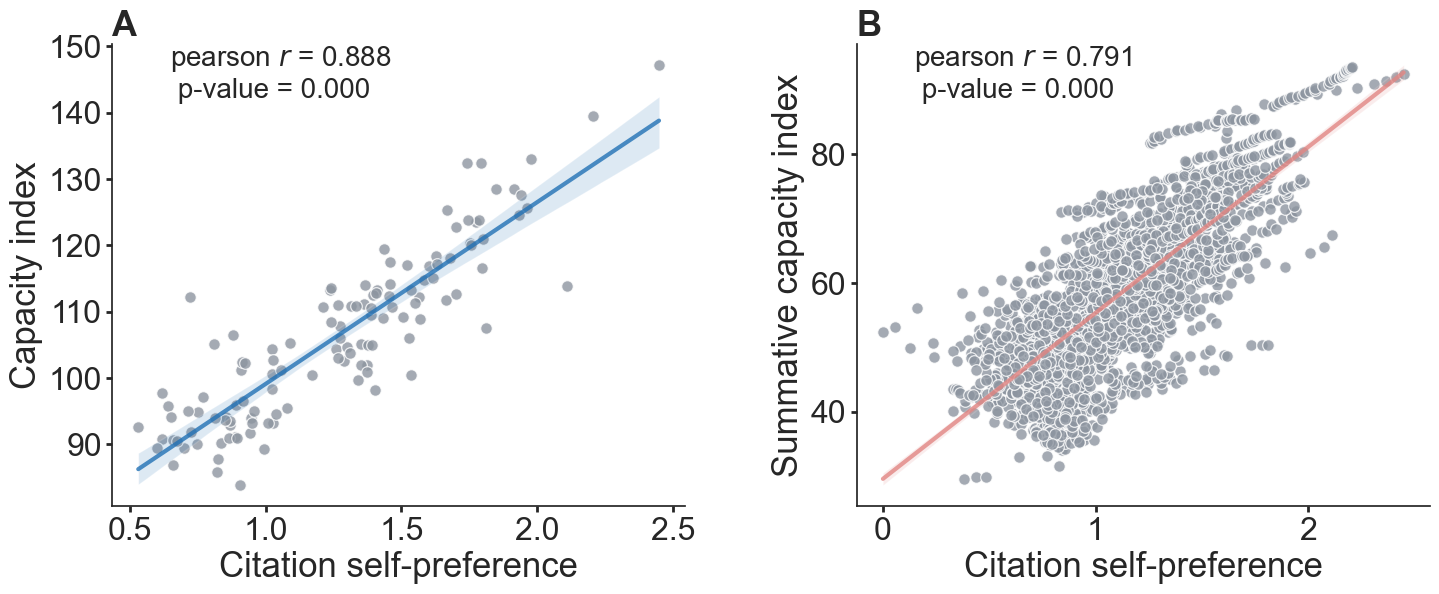

In [91]:
layout = [
    ["A", "B",],
    #['C','D']
    
]

fig, axes = plt.subplot_mosaic(layout, figsize=(17,6), 
                                  gridspec_kw={'height_ratios': [1,],  "hspace": 0.2,  "wspace": 0.3},
                                 constrained_layout=False, )
for label, ax in axes.items():
    ax.set_title(label, loc='left', fontweight='bold', fontsize=25, )  # Title at the upper left corner
    ax.title.set_x(-10)

correlation_plot(data2017, 'logzscore','cap_ind', axes['A'], 'Citation self-preference','Capacity index',1)
#correlation_plot(data2017,'FracInternationalAuthors','cap_ind', axes['B'],'International collaboration','Capacity index',1)

correlation_plot(data_index, 'logzscore','cap_sum_index',  axes['B'],'Citation self-preference', 'Summative capacity index',3)
#correlation_plot(data_index,'FracInternationalAuthors','cap_sum_index', axes['D'],'International collaboration', 'Summative capacity index',3)


plt.savefig(f"FigureSelfCitation/NewData/SI_capacityVSzscore_noselfauthor.pdf", bbox_inches='tight')

In [ ]:
countries = ['US','GB', 'DE', 'FR', 'JP', 'NL', 'CH', 'CN', 'IN', 'BR', 'SA','IR']


Text(0.5, 1.0, 'Standardized Measures for US')

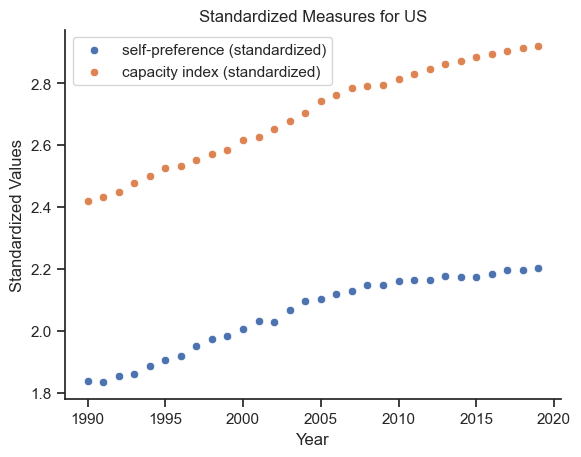

In [128]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

country = 'US'
country_data = data_index[data_index['Country'] == country].copy()

# Standardize the measures
scaler = StandardScaler()
country_data['logzscore_std'] = scaler.fit_transform(country_data[['logzscore']])
country_data['cap_sum_index_std'] = scaler.fit_transform(country_data[['cap_sum_index']])

# Plot with standardized values
ax = sns.scatterplot(data=country_data, x='Year', y='logzscore', label='self-preference (standardized)')
sns.scatterplot(data=country_data, x='Year', y='cap_sum_index', label='capacity index (standardized)', ax=ax)
plt.ylabel('Standardized Values')
plt.title(f'Standardized Measures for {country}')

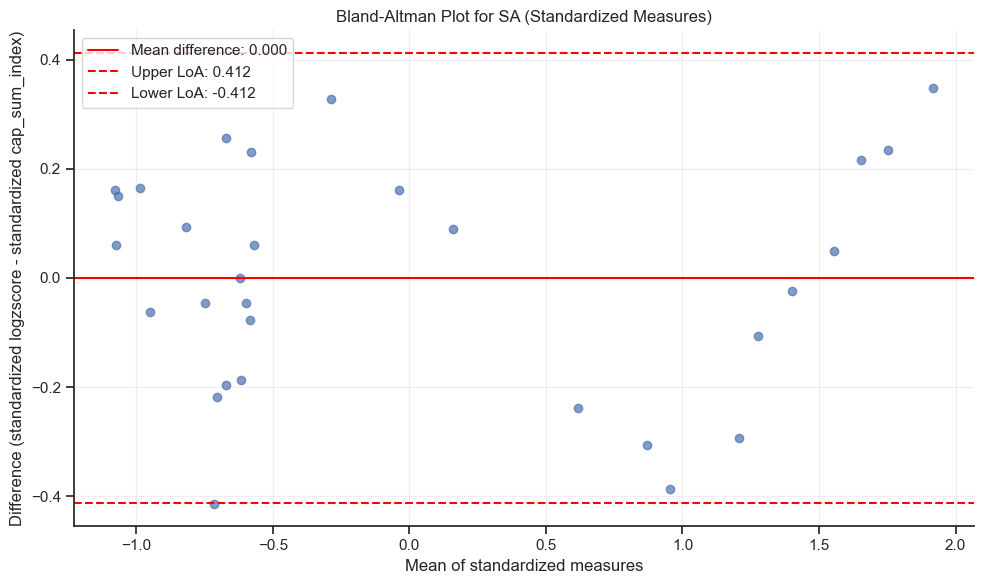

In [126]:
from sklearn.preprocessing import StandardScaler

country = 'SA'
country_data = data_index[data_index['Country'] == country].copy()

# Standardize the measures first
scaler = StandardScaler()
measure1_std = scaler.fit_transform(country_data[['logzscore']]).flatten()
measure2_std = scaler.fit_transform(country_data[['cap_sum_index']]).flatten()

# Calculate mean and difference for standardized measures
mean_values = (measure1_std + measure2_std) / 2
diff_values = measure1_std - measure2_std

# Calculate statistics
mean_diff = np.mean(diff_values)
std_diff = np.std(diff_values, ddof=1)
upper_limit = mean_diff + 1.96 * std_diff
lower_limit = mean_diff - 1.96 * std_diff

# Create the plot
plt.figure(figsize=(10, 6))
plt.scatter(mean_values, diff_values, alpha=0.7)
plt.axhline(mean_diff, color='red', linestyle='-', label=f'Mean difference: {mean_diff:.3f}')
plt.axhline(upper_limit, color='red', linestyle='--', label=f'Upper LoA: {upper_limit:.3f}')
plt.axhline(lower_limit, color='red', linestyle='--', label=f'Lower LoA: {lower_limit:.3f}')

plt.xlabel('Mean of standardized measures')
plt.ylabel('Difference (standardized logzscore - standardized cap_sum_index)')
plt.title(f'Bland-Altman Plot for {country} (Standardized Measures)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [92]:
import statsmodels.formula.api as smf
from stargazer.stargazer import Stargazer


datac1 = data2017.dropna(subset=['logzscore', 'cap_ind',])

datac2 = data_index.dropna(subset=['logzscore', 'cap_sum_index', 'Country', 'Year'])

for i in ['logzscore', 'cap_ind',]:
    datac1[i]=(datac1[i]-datac1[i].mean())/datac1[i].std()
    
for i in ['logzscore', 'cap_sum_index',]:
    datac2[i]=(datac2[i]-datac2[i].mean())/datac2[i].std()

m0 = smf.ols(formula=' cap_ind ~  logzscore', data=datac1).fit()

m1 = smf.ols(formula=' cap_sum_index ~  logzscore', data=datac2).fit()

m2 = smf.ols(formula=' cap_sum_index ~  logzscore +C(Country)+C(Year)', data=datac2).fit(cov_type='cluster', 
                                  cov_kwds={'groups': datac2['Country']})



stargazer = Stargazer([m0, m1,m2])
stargazer.covariate_order(['logzscore',])  # keep only logzscore

# Output LaTeX code
latex_str=stargazer.render_latex()


print(latex_str)

\begin{table}[!htbp] \centering
\begin{tabular}{@{\extracolsep{5pt}}lccc}
\\[-1.8ex]\hline
\hline \\[-1.8ex]
\\[-1.8ex] & (1) & (2) & (3) \\
\hline \\[-1.8ex]
 logzscore & 0.888$^{***}$ & 0.791$^{***}$ & 0.248$^{***}$ \\
& (0.042) & (0.012) & (0.025) \\
\hline \\[-1.8ex]
 Observations & 123 & 2411 & 2411 \\
 $R^2$ & 0.788 & 0.625 & 0.990 \\
 Adjusted $R^2$ & 0.787 & 0.625 & 0.990 \\
 Residual Std. Error & 0.462 (df=121) & 0.612 (df=2409) & 0.102 (df=2254) \\
 F Statistic & 450.872$^{***}$ (df=1; 121) & 4015.139$^{***}$ (df=1; 2409) & 5630.871$^{***}$ (df=156; 2254) \\
\hline
\hline \\[-1.8ex]
\textit{Note:} & \multicolumn{3}{r}{$^{*}$p$<$0.1; $^{**}$p$<$0.05; $^{***}$p$<$0.01} \\
\end{tabular}
\end{table}


/var/folders/pw/3c9bpx2x49j17_0h64t91zgr0000gr/T/ipykernel_99639/2260233025.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  datac1[i]=(datac1[i]-datac1[i].mean())/datac1[i].std()
/var/folders/pw/3c9bpx2x49j17_0h64t91zgr0000gr/T/ipykernel_99639/2260233025.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  datac2[i]=(datac2[i]-datac2[i].mean())/datac2[i].std()
/Users/psp2nq/anaconda3/envs/bigdata/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does n

# regression

In [59]:
data2017.columns

Index(['CitingCountry', 'Year', 'Country', 'AUC', 'Cov', 'N', 'zscore',
       'pvalue', 'significant', 'NumPub', 'TopJournal', 'FracTop', 'OANumPub',
       'OATopJournal', 'OAFracTop', 'normalized_frac_top', 'logNumPub',
       'FractionNationalAuthors', 'FracInternationalAuthors',
       'TopicDiversity1', 'TopicDiversity2', 'RND_per', 'PAT_res', 'PAT_nres',
       'GDP', 'GDP_PCAP', 'GNI', 'GNI_PCAP', 'NResearchers', 'Pop',
       'PAT_total', 'logPop', 'pub_capita', 'income_level', 'sig_direction',
       'developed', 'income_group', 'logzscore', 'country_code', 'cap_ind',
       'gov_ind', 'interaction_term', 'cap_sum_index', 'gov_sum_index',
       'cap_sum_index_alt', 'int_sum_term'],
      dtype='object')

In [93]:
import statsmodels.formula.api as smf
from stargazer.stargazer import Stargazer
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
data2017[[ 'cap_ind']] = scaler.fit_transform(data2017[['cap_ind']])
data_index[[ 'cap_sum_index']] = scaler.fit_transform(data_index[['cap_sum_index']])

data2017['NResearchers']=np.log10(data2017['NResearchers'])
data_index['NResearchers']=np.log10(data_index['NResearchers'])

for i in ['FracInternationalAuthors', 'NResearchers','RND_per','GDP_PCAP' ]:
    data2017[[ i]] = scaler.fit_transform(data2017[[i]])
    data_index[[ i]] = scaler.fit_transform(data_index[[i]])


In [98]:
m1 = smf.ols(formula=' normalized_frac_top ~ GDP_PCAP+RND_per+NResearchers+ cap_ind', data=data2017).fit()
m2 = smf.ols(formula=' normalized_frac_top ~ GDP_PCAP+RND_per+NResearchers+ FracInternationalAuthors+ cap_ind', data=data2017).fit()
m3 = smf.ols(formula=' normalized_frac_top ~ GDP_PCAP+RND_per+NResearchers+ FracInternationalAuthors*cap_ind', data=data2017).fit()


data_clean2 = data_index.dropna(subset=['normalized_frac_top','FracInternationalAuthors', 'cap_sum_index', 'Country', 'Year', 'NResearchers','RND_per','GDP_PCAP'])

m11 = smf.ols(formula=' normalized_frac_top ~ GDP_PCAP+RND_per+NResearchers+ cap_sum_index+C(Country)+C(Year)', data=data_clean2).fit(cov_type='cluster', 
                                  cov_kwds={'groups': data_clean2['Country']})

m22 = smf.ols(formula=' normalized_frac_top ~ GDP_PCAP+RND_per+NResearchers+ FracInternationalAuthors+cap_sum_index+C(Country)+C(Year)', data=data_clean2).fit(cov_type='cluster', 
                                  cov_kwds={'groups': data_clean2['Country']})
m33 = smf.ols(formula=' normalized_frac_top ~ GDP_PCAP+RND_per+NResearchers+ FracInternationalAuthors*cap_sum_index+C(Country)+C(Year)', data=data_clean2).fit(cov_type='cluster', 
                                  cov_kwds={'groups': data_clean2['Country']})


stargazer = Stargazer([m1, m2,m3, m11,m22,m33])
stargazer.covariate_order(['GDP_PCAP','RND_per','NResearchers','FracInternationalAuthors','cap_ind','FracInternationalAuthors:cap_ind','cap_sum_index','FracInternationalAuthors:cap_sum_index'])  # keep only logzscore

latex_str=stargazer.render_latex()

print(latex_str)

\begin{table}[!htbp] \centering
\begin{tabular}{@{\extracolsep{5pt}}lcccccc}
\\[-1.8ex]\hline
\hline \\[-1.8ex]
& \multicolumn{6}{c}{\textit{Dependent variable: normalized_frac_top}} \
\cr \cline{2-7}
\\[-1.8ex] & (1) & (2) & (3) & (4) & (5) & (6) \\
\hline \\[-1.8ex]
 GDP_PCAP & 0.161$^{***}$ & 0.068$^{}$ & 0.075$^{*}$ & -0.208$^{}$ & 0.090$^{}$ & 0.134$^{}$ \\
& (0.056) & (0.041) & (0.041) & (0.129) & (0.102) & (0.111) \\
 RND_per & 0.151$^{***}$ & 0.060$^{*}$ & 0.052$^{}$ & 0.070$^{**}$ & 0.046$^{**}$ & 0.030$^{}$ \\
& (0.048) & (0.036) & (0.036) & (0.029) & (0.022) & (0.026) \\
 NResearchers & -0.010$^{}$ & 0.024$^{}$ & 0.036$^{}$ & -0.047$^{}$ & -0.049$^{*}$ & -0.052$^{**}$ \\
& (0.050) & (0.035) & (0.036) & (0.034) & (0.027) & (0.024) \\
 FracInternationalAuthors & & 0.225$^{***}$ & 0.235$^{***}$ & & 0.225$^{***}$ & 0.206$^{***}$ \\
& & (0.028) & (0.028) & & (0.041) & (0.029) \\
 cap_ind & -0.017$^{}$ & 0.131$^{***}$ & 0.118$^{***}$ & & & \\
& (0.033) & (0.030) & (0.031) & & & \\

/Users/psp2nq/anaconda3/envs/bigdata/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 123, but rank is 27
  warnings.warn('covariance of constraints does not have full '
/Users/psp2nq/anaconda3/envs/bigdata/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 124, but rank is 28
  warnings.warn('covariance of constraints does not have full '
/Users/psp2nq/anaconda3/envs/bigdata/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 125, but rank is 29
  warnings.warn('covariance of constraints does not have full '


In [131]:
mm= smf.ols(formula=' normalized_frac_top ~ GDP_PCAP+RND_per+NResearchers+ cap_sum_index+logzscore+C(Country)+C(Year)', data=data_clean2).fit(cov_type='cluster', 
                                  cov_kwds={'groups': data_clean2['Country']})
mm2 = smf.ols(formula=' normalized_frac_top ~ GDP_PCAP+RND_per+NResearchers+ FracInternationalAuthors+ cap_ind+logzscore', data=data2017).fit()


In [132]:
mm2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                            
===============================================================================
Dep. Variable:     normalized_frac_top   R-squared:                       0.781
Model:                             OLS   Adj. R-squared:                  0.760
Method:                  Least Squares   F-statistic:                     36.83
Date:                 Mon, 11 Aug 2025   Prob (F-statistic):           1.19e-18
Time:                         16:47:53   Log-Likelihood:                 33.237
No. Observations:                   69   AIC:                            -52.47
Df Residuals:                       62   BIC:                            -36.83
Df Model:                            6                                         
Covariance Type:             nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                    0.7695      0.140      5.487      0.000       0.489       1.050
GDP_PCAP                     0.0691      0.041      1.683      0.097      -0.013       0.151
RND_per                      0.0572      0.035      1.617      0.111      -0.014       0.128
NResearchers                 0.0342      0.036      0.953      0.344      -0.038       0.106
FracInternationalAuthors     0.2289      0.028      8.228      0.000       0.173       0.285
cap_ind                      0.0756      0.050      1.523      0.133      -0.024       0.175
logzscore                    0.1526      0.110      1.390      0.170      -0.067       0.372
==============================================================================
Omnibus:                        7.970   Durbin-Watson:                   2.023
Prob(Omnibus):                  0.019   Jarque-Bera (JB):                8.050
Skew:                           0.592   Prob(JB):                       0.0179
Kurtosis:                       4.182   Cond. No.                         18.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [99]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.formula.api import ols
import warnings
warnings.filterwarnings('ignore')

def calculate_vif(data, formula, model_name):
    """
    Calculate VIF for continuous variables in a regression model
    """
    print(f"\n=== VIF Analysis for {model_name} ===")
    
    # Extract continuous variables from the formula (excluding categorical variables and interactions)
    # Parse the formula to get variable names
    if 'FracInternationalAuthors*cap_ind' in formula:
        continuous_vars = ['GDP_PCAP', 'RND_per', 'NResearchers', 'FracInternationalAuthors', 'cap_ind']
    elif 'FracInternationalAuthors*cap_sum_index' in formula:
        continuous_vars = ['GDP_PCAP', 'RND_per', 'NResearchers', 'FracInternationalAuthors', 'cap_sum_index']
    elif 'FracInternationalAuthors' in formula and 'cap_ind' in formula:
        continuous_vars = ['GDP_PCAP', 'RND_per', 'NResearchers', 'FracInternationalAuthors', 'cap_ind']
    elif 'FracInternationalAuthors' in formula and 'cap_sum_index' in formula:
        continuous_vars = ['GDP_PCAP', 'RND_per', 'NResearchers', 'FracInternationalAuthors', 'cap_sum_index']
    elif 'cap_ind' in formula:
        continuous_vars = ['GDP_PCAP', 'RND_per', 'NResearchers', 'cap_ind']
    elif 'cap_sum_index' in formula:
        continuous_vars = ['GDP_PCAP', 'RND_per', 'NResearchers', 'cap_sum_index']
    else:
        continuous_vars = ['GDP_PCAP', 'RND_per', 'NResearchers']
    
    # Check which variables are actually in the data
    available_vars = [var for var in continuous_vars if var in data.columns]
    
    if len(available_vars) < 2:
        print("Not enough continuous variables for VIF calculation")
        return None
    
    # Remove rows with missing values for these variables
    data_clean = data[available_vars].dropna()
    
    if len(data_clean) == 0:
        print("No complete observations available")
        return None
    
    # Calculate VIF for each variable
    vif_data = pd.DataFrame()
    vif_data["Variable"] = available_vars
    vif_data["VIF"] = [variance_inflation_factor(data_clean.values, i) 
                       for i in range(len(available_vars))]
    
    # Sort by VIF value
    vif_data = vif_data.sort_values('VIF', ascending=False)
    
    print(vif_data.to_string(index=False, float_format='%.2f'))
    
    # Flag high VIF values
    high_vif = vif_data[vif_data['VIF'] > 5]
    if len(high_vif) > 0:
        print(f"\n⚠️  Variables with VIF > 5 (potential multicollinearity):")
        print(high_vif.to_string(index=False, float_format='%.2f'))
    
    very_high_vif = vif_data[vif_data['VIF'] > 10]
    if len(very_high_vif) > 0:
        print(f"\n🚨 Variables with VIF > 10 (serious multicollinearity):")
        print(very_high_vif.to_string(index=False, float_format='%.2f'))
    
    return vif_data

# Model formulas
models = {
    'M1': 'normalized_frac_top ~ GDP_PCAP+RND_per+NResearchers+ cap_ind',
    'M2': 'normalized_frac_top ~ GDP_PCAP+RND_per+NResearchers+ FracInternationalAuthors+ cap_ind',
    'M3': 'normalized_frac_top ~ GDP_PCAP+RND_per+NResearchers+ FracInternationalAuthors*cap_ind',
    'M11': 'normalized_frac_top ~ GDP_PCAP+RND_per+NResearchers+ cap_sum_index+C(Country)+C(Year)',
    'M22': 'normalized_frac_top ~ GDP_PCAP+RND_per+NResearchers+ FracInternationalAuthors+cap_sum_index+C(Country)+C(Year)',
    'M33': 'normalized_frac_top ~ GDP_PCAP+RND_per+NResearchers+ FracInternationalAuthors*cap_sum_index+C(Country)+C(Year)'
}

# Note: You'll need to replace 'data2017' and 'data_clean2' with your actual dataframes
print("📊 VIF Analysis for All Models")
print("="*50)
print("Note: VIF > 5 suggests potential multicollinearity")
print("Note: VIF > 10 suggests serious multicollinearity")
print("Note: Categorical variables (Country, Year) are excluded from VIF calculation")

# For models 1-3 (using data2017)
print("\n" + "="*20 + " CROSS-SECTIONAL MODELS (2017) " + "="*20)
try:
    for model_name, formula in list(models.items())[:3]:
        calculate_vif(data2017, formula, model_name)
except NameError:
    print("⚠️  'data2017' not found. Please ensure the dataframe is loaded.")
    print("Using placeholder data structure for demonstration:")
    # Create example VIF calculation code
    print("""
    # Example VIF calculation for your models:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    
    # For Model 1:
    vars_m1 = ['GDP_PCAP', 'RND_per', 'NResearchers', 'cap_ind']
    data_m1 = data2017[vars_m1].dropna()
    vif_m1 = pd.DataFrame({
        'Variable': vars_m1,
        'VIF': [variance_inflation_factor(data_m1.values, i) for i in range(len(vars_m1))]
    })
    print(vif_m1)
    """)

# For models 11-33 (using data_clean2)
print("\n" + "="*20 + " PANEL DATA MODELS " + "="*20)
try:
    for model_name, formula in list(models.items())[3:]:
        calculate_vif(data_clean2, formula, model_name)
except NameError:
    print("⚠️  'data_clean2' not found. Please ensure the dataframe is loaded.")

print("\n" + "="*70)
print("📋 VIF Interpretation Guide:")
print("• VIF = 1: No multicollinearity")
print("• 1 < VIF < 5: Moderate multicollinearity (usually acceptable)")
print("• 5 < VIF < 10: High multicollinearity (concerning)")
print("• VIF > 10: Very high multicollinearity (problematic)")
print("\n💡 Solutions for high VIF:")
print("• Remove highly correlated variables")
print("• Use principal component analysis (PCA)")
print("• Ridge regression or other regularization methods")
print("• Center variables (especially for interaction terms)")

📊 VIF Analysis for All Models
Note: VIF > 5 suggests potential multicollinearity
Note: VIF > 10 suggests serious multicollinearity
Note: Categorical variables (Country, Year) are excluded from VIF calculation

==================== CROSS-SECTIONAL MODELS (2017) ====================

=== VIF Analysis for M1 ===
    Variable  VIF
NResearchers 2.74
     RND_per 2.48
    GDP_PCAP 2.15
     cap_ind 1.39

=== VIF Analysis for M2 ===
                Variable  VIF
                 RND_per 2.90
            NResearchers 2.75
                 cap_ind 2.53
                GDP_PCAP 2.24
FracInternationalAuthors 1.90

=== VIF Analysis for M3 ===
                Variable  VIF
                 RND_per 2.90
            NResearchers 2.75
                 cap_ind 2.53
                GDP_PCAP 2.24
FracInternationalAuthors 1.90

==================== PANEL DATA MODELS ====================

=== VIF Analysis for M11 ===
     Variable  VIF
      RND_per 2.95
 NResearchers 2.75
     GDP_PCAP 2.09
cap_sum_index 

In [72]:



m1 = smf.ols(formula=' normalized_frac_top ~  cap_ind', data=data2017).fit()
m2 = smf.ols(formula=' normalized_frac_top ~  FracInternationalAuthors + cap_ind', data=data2017).fit()
m22 = smf.ols(formula=' normalized_frac_top ~  FracInternationalAuthors*cap_ind', data=data2017).fit()

data_clean1 = data_index.dropna(subset=['normalized_frac_top', 'cap_sum_index', 'Country', 'Year'])

m3 = smf.ols(formula=' normalized_frac_top ~  cap_sum_index +C(Country)+C(Year)', data=data_clean1).fit(cov_type='cluster', 
                                  cov_kwds={'groups': data_clean1['Country']})

data_clean2 = data_index.dropna(subset=['normalized_frac_top','FracInternationalAuthors', 'cap_sum_index', 'Country', 'Year'])

m4 = smf.ols(formula=' normalized_frac_top ~ FracInternationalAuthors + cap_sum_index +C(Country)+C(Year)', data=data_clean2).fit(cov_type='cluster', 
                                  cov_kwds={'groups': data_clean2['Country']})

m5 = smf.ols(formula=' normalized_frac_top ~ FracInternationalAuthors*cap_sum_index +C(Country)+C(Year)', data=data_clean2).fit(cov_type='cluster', 
                                  cov_kwds={'groups': data_clean2['Country']})

# It’s conceptually distinct
# It adds value for  interpretation



stargazer = Stargazer([m1, m2,m22,m3,m4,m5])
stargazer.covariate_order(['FracInternationalAuthors','cap_ind','FracInternationalAuthors:cap_ind','cap_sum_index','FracInternationalAuthors:cap_sum_index'])  # keep only logzscore

# Output LaTeX code
latex_str=stargazer.render_latex()


print(latex_str)

\begin{table}[!htbp] \centering
\begin{tabular}{@{\extracolsep{5pt}}lcccccc}
\\[-1.8ex]\hline
\hline \\[-1.8ex]
& \multicolumn{6}{c}{\textit{Dependent variable: normalized_frac_top}} \
\cr \cline{2-7}
\\[-1.8ex] & (1) & (2) & (3) & (4) & (5) & (6) \\
\hline \\[-1.8ex]
 FracInternationalAuthors & & 0.243$^{***}$ & 0.242$^{***}$ & & 0.170$^{***}$ & 0.170$^{***}$ \\
& & (0.022) & (0.022) & & (0.021) & (0.020) \\
 cap_ind & 0.113$^{***}$ & 0.235$^{***}$ & 0.246$^{***}$ & & & \\
& (0.027) & (0.022) & (0.022) & & & \\
 FracInternationalAuthors:cap_ind & & & 0.050$^{***}$ & & & \\
& & & (0.017) & & & \\
 cap_sum_index & & & & -0.018$^{}$ & 0.148$^{***}$ & 0.210$^{***}$ \\
& & & & (0.052) & (0.053) & (0.064) \\
 FracInternationalAuthors:cap_sum_index & & & & & & 0.043$^{***}$ \\
& & & & & & (0.013) \\
\hline \\[-1.8ex]
 Observations & 123 & 123 & 123 & 2411 & 2411 & 2411 \\
 $R^2$ & 0.129 & 0.562 & 0.590 & 0.816 & 0.882 & 0.889 \\
 Adjusted $R^2$ & 0.121 & 0.555 & 0.579 & 0.803 & 0.874 & 0.881

/Users/psp2nq/anaconda3/envs/bigdata/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 156, but rank is 30
  warnings.warn('covariance of constraints does not have full '
/Users/psp2nq/anaconda3/envs/bigdata/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 157, but rank is 31
  warnings.warn('covariance of constraints does not have full '
/Users/psp2nq/anaconda3/envs/bigdata/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 158, but rank is 32
  warnings.warn('covariance of constraints does not have full '


# consider lag

In [67]:
indexsum=pd.read_csv('CountryData/panel_sum_index_1990_2020.csv')
indexsum.sort_values(by=['country_code','date'], inplace=True)
indexsum=indexsum[['country_code','date','cap_sum_index', 'gov_sum_index',]]
indexsum['country_code']=indexsum['country_code'].str.strip()
indexsum['country_code'] = indexsum['country_code'].map(country_dict)

data_index=data.merge(indexsum, how='left',left_on=['Country','Year'], right_on=['country_code','date'])

In [72]:
for i in [0,1,2,3]:
    
    data_index['index_lag'] = data_index['cap_sum_index'].shift(i)
    cor=data_index['index_lag'].corr(data_index['logzscore'])
    print(cor)

0.7340282862225048
0.6809986241083053
0.6384551747217869
0.603442998601616


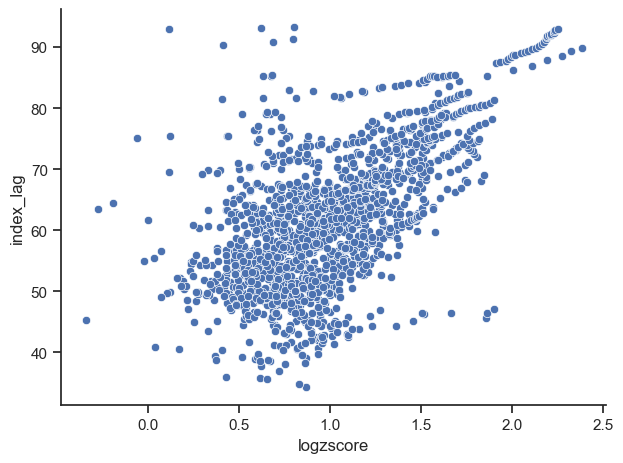

In [160]:
ax=sns.scatterplot(data=data_index, x='logzscore',y='index_lag')

# for i in range(data_index.shape[0]):
#     ax.text(
#         data_index['index_lag'].iloc[i],
#         data_index['logzscore'].iloc[i],
#         data_index['Country'].iloc[i],  # replace with the column name for country
#         fontsize=8, 
#         alpha=0.7
#     )
plt.tight_layout()
plt.show()

In [85]:
model = smf.ols(formula='cap_sum_index  ~   logzscore + C(Country) + C(Year)+C(developed)', data=data_index).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          cap_sum_index   R-squared:                       0.988
Model:                            OLS   Adj. R-squared:                  0.987
Method:                 Least Squares   F-statistic:                     1007.
Date:                Wed, 04 Jun 2025   Prob (F-statistic):               0.00
Time:                        14:43:31   Log-Likelihood:                -2785.0
No. Observations:                1723   AIC:                             5824.
Df Residuals:                    1596   BIC:                             6516.
Df Model:                         126                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            46.0935      0.480     96.124      0.000      45.153      47.034
C(Country)[T.AR]      6.6122      0.501     13.186      0.000       5.629       7.596
C(Country)[T.AT]     11.7341      0.473     24.807      0.000      10.806      12.662
C(Country)[T.AU]     14.2915      0.519     27.532      0.000      13.273      15.310
C(Country)[T.BD]     -4.0855      0.555     -7.365      0.000      -5.174      -2.997
C(Country)[T.BE]     11.1234      0.475     23.400      0.000      10.191      12.056
C(Country)[T.BF]    -14.7671      0.679    -21.740      0.000     -16.099     -13.435
C(Country)[T.BG]      0.7840      0.540      1.452      0.147      -0.275       1.843
C(Country)[T.BJ]     -8.5425      1.348     -6.339      0.000     -11.186      -5.899
C(Country)[T.BR]     13.7163      0.541     25.369      0.000      12.656      14.777
C(Country)[T.BY]     -0.8542      0.634     -1.348      0.178      -2.097       0.389
C(Country)[T.CA]     17.1018      0.509     33.596      0.000      16.103      18.100
C(Country)[T.CD]    -14.2524      1.349    -10.561      0.000     -16.899     -11.605
C(Country)[T.CH]     13.3284      0.488     27.316      0.000      12.371      14.285
C(Country)[T.CL]      1.9064      0.502      3.795      0.000       0.921       2.892
C(Country)[T.CM]     -8.1570      0.560    -14.561      0.000      -9.256      -7.058
C(Country)[T.CN]     24.4301      0.540     45.258      0.000      23.371      25.489
C(Country)[T.CO]      0.4731      0.531      0.891      0.373      -0.568       1.514
C(Country)[T.CR]     -8.8506      0.721    -12.277      0.000     -10.265      -7.437
C(Country)[T.CU]     -2.0905      0.596     -3.509      0.000      -3.259      -0.922
C(Country)[T.CY]     -7.3327      0.698    -10.508      0.000      -8.701      -5.964
C(Country)[T.CZ]      7.1434      0.482     14.817      0.000       6.198       8.089
C(Country)[T.DE]     23.3585      0.523     44.675      0.000      22.333      24.384
C(Country)[T.DK]      9.1795      0.485     18.914      0.000       8.227      10.131
C(Country)[T.DZ]     -1.0130      0.561     -1.806      0.071      -2.113       0.087
C(Country)[T.EC]     -7.0113      0.678    -10.339      0.000      -8.341      -5.681
C(Country)[T.EE]     -3.7504      0.547     -6.856      0.000      -4.823      -2.677
C(Country)[T.EG]      4.4839      0.504      8.901      0.000       3.496       5.472
C(Country)[T.ES]     16.0516      0.503     31.927      0.000      15.065      17.038
C(Country)[T.ET]    -10.7934      0.579    -18.644      0.000     -11.929      -9.658
C(Country)[T.FI]      9.6645      0.485     19.945      0.000       8.714      10.615
C(Country)[T.FR]     20.9292      0.513     40.778      0.000      19.922      21.936
C(Country)[T.GB]     21.4076      0.542     39.530      0.000      20.345

In [ ]:
import copy

custom_params = {"axes.spines.bottom": True, "axes.spines.right": False, "axes.spines.top": False,
                 "axes.spines.left": True,"ytick.left":True, "xtick.bottom":True}
sns.set_theme(style='ticks', rc=custom_params)
    

# dfself_vars=pd.read_csv('RegressionSelfCitation/SelfCitation_Plus_Covariates.csv')

# data=dfself_vars[(dfself_vars['Year']<=2017)&(dfself_vars['Year']>=1990)]
# data=data.dropna(subset=['FracInternationalAuthors','zscore',])


df=copy.deepcopy(data_index)
#df=df[df['significant']==True]
num_quantiles = 4
#quantile_labels = [f'Q{i + 1}' for i in range(num_quantiles)]
quantile_labels= ['Bottom 25%', '50-75%','25-50%','Top 25%']
df['quantile'] = df.groupby('Year')['normalized_frac_top'].transform(lambda x: pd.qcut(x, num_quantiles, labels=quantile_labels))



df_alter=five_year_interval(df)

plt.figure(figsize=(13, 8))

# color_palette = sns.color_palette('coolwarm', num_quantiles) 
# color_dic=dict(zip(quantile_labels,color_palette))



color_dic = {
    'Bottom 25%': '#5471AB',
    'Top 25%': '#DC143C',
    '25-50%': 'lightcoral',
    '50-75%': '#84A0F3',
    
}

marker_dic = {
    'Bottom 25%': 'o',
    'Top 25%': 's',
    '25-50%': '>',
    '50-75%': 'D',
   
}


line_dic = {
    'Bottom 25%': '-',
    'Top 25%': ':',
    '25-50%': '-.',
    '50-75%': '--',
}

for quantile in quantile_labels:
    quantile_data = df[df['quantile'] == quantile]
    ax=sns.regplot(x='logzscore', y='FracInternationalAuthors', data=quantile_data, x_bins=np.arange(-1, 2.5, 0.2), marker= marker_dic[quantile],
                scatter_kws={'alpha': 0.95, 'color': color_dic[quantile], 'edgecolor':'w', 's':100, }, 
                line_kws={'color': color_dic[quantile], 'label': quantile, 'lw':4, 'linestyle':line_dic[quantile]}, order=1, )

#plt.grid(axis='y')
for spine in ax.spines.values():
        spine.set_linewidth(1.5) 

plt.tick_params(labelsize=22, direction='out', length=4, width=2) 

plt.xlabel('Country self-preference', fontsize=25)
plt.ylabel('Fraction with international authors', fontsize=25)


custom_order = ['Top 25%','25-50%', '50-75%' ,'Bottom 25%']  # Desired order of categories
handles, labels = ax.get_legend_handles_labels()
ordered_handles = [handles[labels.index(cat)] for cat in custom_order]
ordered_labels = custom_order

#ax.legend(ordered_handles, ordered_labels, frameon=False,  title='Country self-preference',fontsize=20, title_fontsize=20, bbox_to_anchor=(1.06, 0.37), borderaxespad=0.5 )

ax.legend(ordered_handles, ordered_labels, loc='center left', ncol=1, frameon=False, fontsize=22, title='Normalized fraction \n in top journals',
           title_fontsize=22, bbox_to_anchor=(1, 0.5),  )
plt.tight_layout()

#plt.savefig(f"FigureSelfCitation/SignificantCountries/collab_self_top_sig.pdf", bbox_inches='tight')
